In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the crime dataset
df = pd.read_csv('crime_data.csv')

# Convert time column to datetime
df['INCIDENTTIME'] = pd.to_datetime(df['INCIDENTTIME'], errors='coerce')

print("Crime data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Crime data loaded successfully!
Dataset shape: (340996, 16)

Column names:
['_id', 'PK', 'CCR', 'HIERARCHY', 'INCIDENTTIME', 'INCIDENTLOCATION', 'CLEAREDFLAG', 'INCIDENTNEIGHBORHOOD', 'INCIDENTZONE', 'INCIDENTHIERARCHYDESC', 'OFFENSES', 'INCIDENTTRACT', 'COUNCIL_DISTRICT', 'PUBLIC_WORKS_DIVISION', 'X', 'Y']

First few rows:
   _id       PK         CCR  HIERARCHY        INCIDENTTIME  \
0    1  2802309  16000001.0         10 2016-01-01 00:00:00   
1    2  2803174  16004547.0         11 2016-01-01 00:01:00   
2    3  2801809  16000367.0          4 2016-01-01 00:10:00   
3    4  2802315  16000035.0         10 2016-01-01 00:15:00   
4    5  2802312  16000024.0          4 2016-01-01 00:16:00   

                                INCIDENTLOCATION CLEAREDFLAG  \
0  400 Block North Shore DR Pittsburgh, PA 15212           Y   
1    5400 Block Carnegie ST Pittsburgh, PA 15201           N   
2  500 Block Mt Pleasant RD Pittsburgh, PA 15214           N   
3         300 Block Wood ST Pittsburgh, PA 15

In [4]:
# Keep only the top crime types to avoid cluttered plots
top_crimes = df['OFFENSES'].value_counts().head(8).index.tolist()
df_clean = df[df['OFFENSES'].isin(top_crimes)].copy()

print(f"Original dataset size: {len(df)}")
print(f"Filtered dataset size: {len(df_clean)}")
print(f"\nTop 8 crime types:")
print(df['OFFENSES'].value_counts().head(8))

Original dataset size: 340996
Filtered dataset size: 118749

Top 8 crime types:
OFFENSES
9999 Miscellaneous Report (No Crime)                              26273
3745 Accidents Involving Damage to Unattended Veh.or Prop.        17920
3921 Theft by Unlawful Taking or Disposition.                     16305
3304 Criminal Mischief.                                           15413
3921(a) Theft by Unlawful Taking or Disposition - Movable item    11779
3934 Theft from Vehicle                                           11239
3743 Accidents Involving Damage to Attended Veh. or Property      10892
2701 Simple Assault.                                               8928
Name: count, dtype: int64


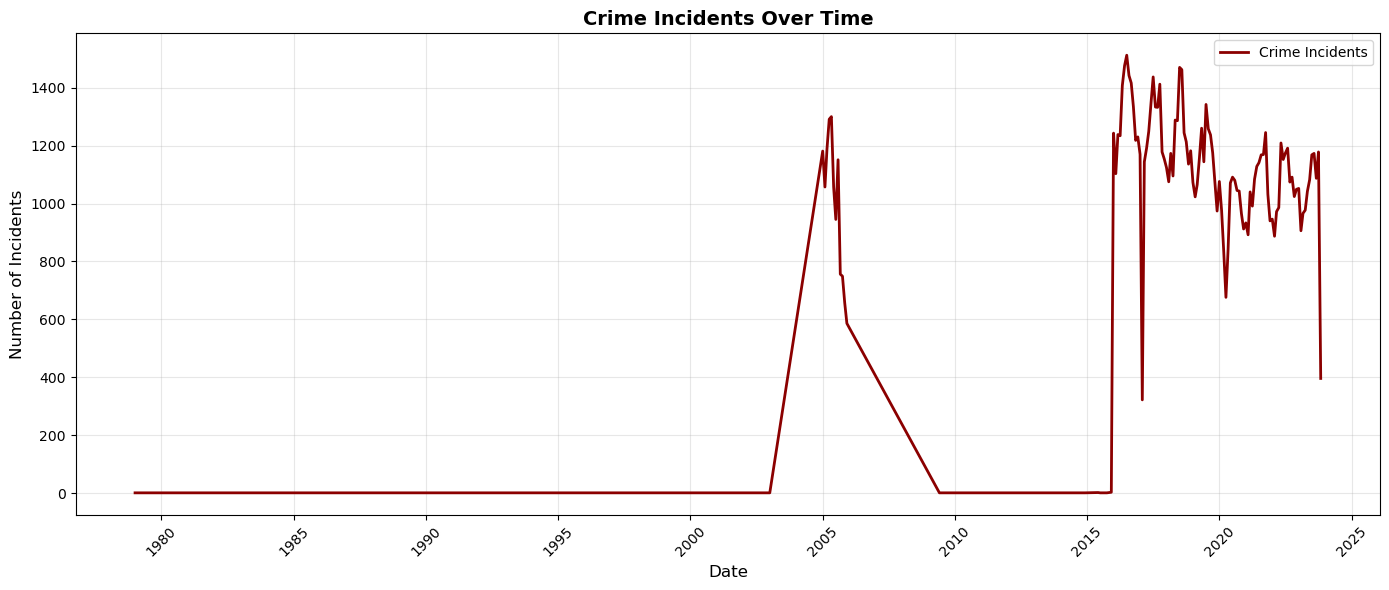

In [5]:
# Count incidents by month
crimes_by_month = df_clean.groupby(df_clean['INCIDENTTIME'].dt.to_period('M')).size()
crimes_by_month.index = crimes_by_month.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(crimes_by_month.index, crimes_by_month.values,
         color='darkred', linewidth=2, label='Crime Incidents')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Crime Incidents Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crime_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

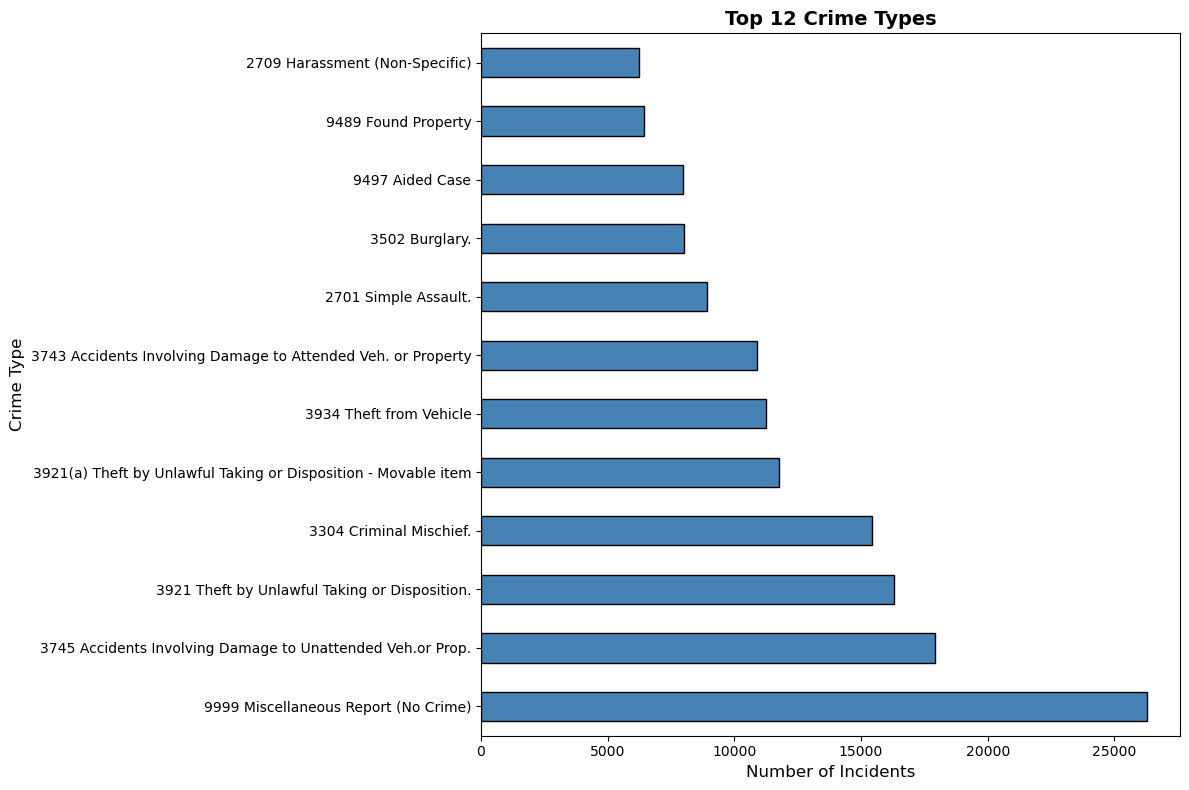

OFFENSES
9999 Miscellaneous Report (No Crime)                              26273
3745 Accidents Involving Damage to Unattended Veh.or Prop.        17920
3921 Theft by Unlawful Taking or Disposition.                     16305
3304 Criminal Mischief.                                           15413
3921(a) Theft by Unlawful Taking or Disposition - Movable item    11779
3934 Theft from Vehicle                                           11239
3743 Accidents Involving Damage to Attended Veh. or Property      10892
2701 Simple Assault.                                               8928
3502 Burglary.                                                     8024
9497 Aided Case                                                    7953
9489 Found Property                                                6451
2709 Harassment (Non-Specific)                                     6224
Name: count, dtype: int64


In [6]:
# Count crimes by type
crimes_by_type = df['OFFENSES'].value_counts().head(12)

plt.figure(figsize=(12, 8))
crimes_by_type.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Crime Type', fontsize=12)
plt.title('Top 12 Crime Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_crime_types.png', dpi=300, bbox_inches='tight')
plt.show()

print(crimes_by_type)

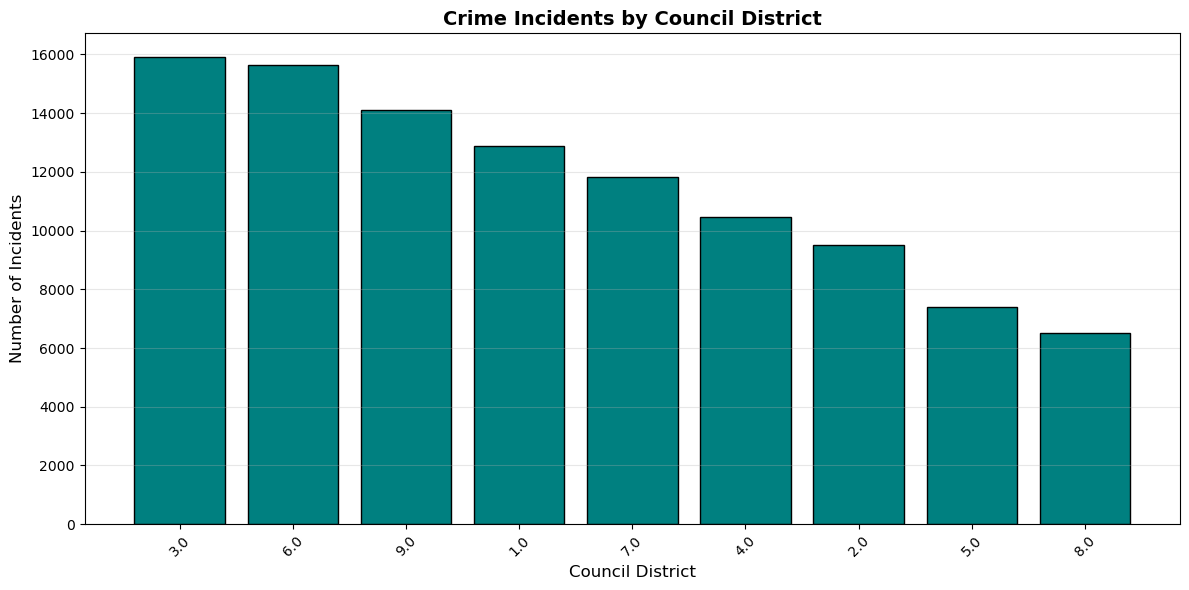

In [7]:
# Count incidents per district
incidents_by_district = df_clean.groupby('COUNCIL_DISTRICT').size().reset_index(name='count')
plt.figure(figsize=(12, 6))
incidents_by_district_sorted = incidents_by_district.sort_values('count', ascending=False)
plt.bar(incidents_by_district_sorted['COUNCIL_DISTRICT'].astype(str),
        incidents_by_district_sorted['count'], color='teal', edgecolor='black')
plt.xlabel('Council District', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Crime Incidents by Council District', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('crime_by_district.png', dpi=300, bbox_inches='tight')
plt.show()

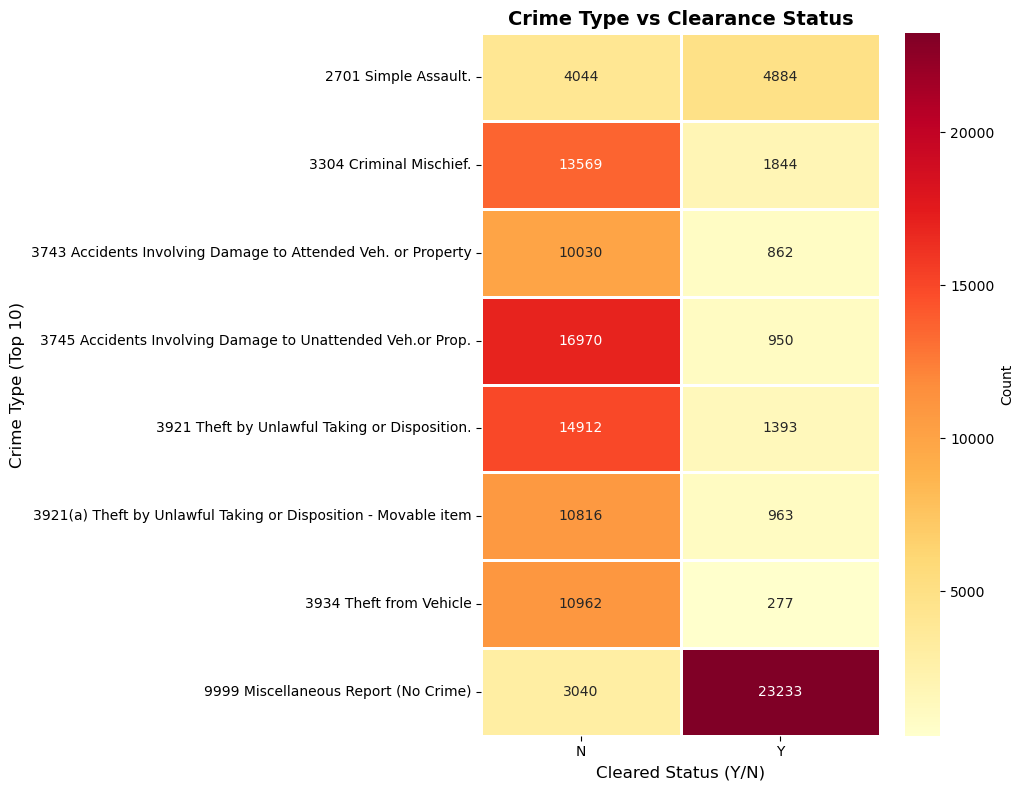

In [8]:
# Create crosstab of top crimes and cleared status
top_10_crimes = df_clean['OFFENSES'].value_counts().head(10).index
crime_cleared = df_clean[df_clean['OFFENSES'].isin(top_10_crimes)].copy()
crosstab = pd.crosstab(crime_cleared['OFFENSES'], crime_cleared['CLEAREDFLAG'])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Count'}, linewidths=1)
plt.xlabel('Cleared Status (Y/N)', fontsize=12)
plt.ylabel('Crime Type (Top 10)', fontsize=12)
plt.title('Crime Type vs Clearance Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('crime_type_vs_cleared_status.png', dpi=300, bbox_inches='tight')
plt.show()

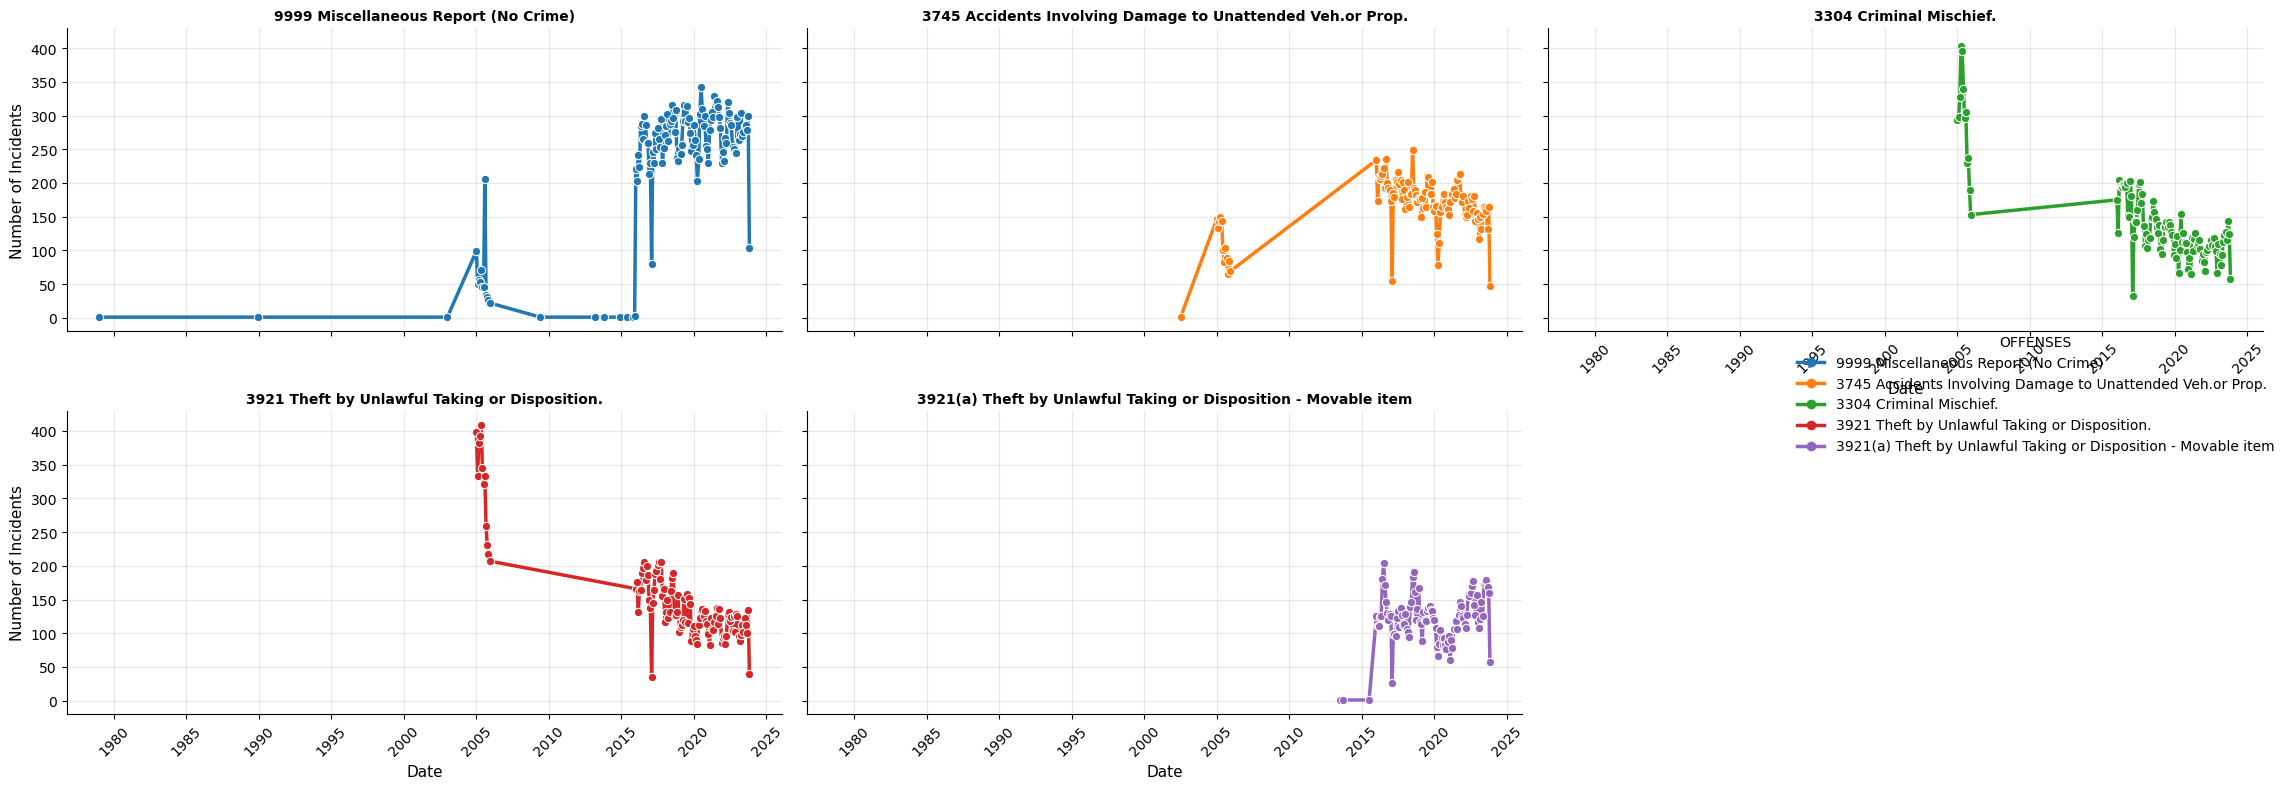

In [9]:
# Prepare data: crimes by month and type
df_time_crime = df_clean.copy()
df_time_crime['YearMonth'] = df_time_crime['INCIDENTTIME'].dt.to_period('M')
crimes_trend = df_time_crime.groupby(['YearMonth', 'OFFENSES']).size().reset_index(name='count')
crimes_trend['YearMonth'] = crimes_trend['YearMonth'].dt.to_timestamp()

# Plot top 5 crime types in separate faceted panels with different colors
top_5_crimes = df_clean['OFFENSES'].value_counts().head(5).index
crimes_trend_filtered = crimes_trend[crimes_trend['OFFENSES'].isin(top_5_crimes)]

# Create faceted plot with separate panel for each crime type and hue
g = sns.relplot(data=crimes_trend_filtered, x='YearMonth', y='count',
                col='OFFENSES', hue='OFFENSES', col_wrap=3, kind='line', 
                height=4, aspect=1.5, linewidth=2.5, marker='o')

g.set_axis_labels('Date', 'Number of Incidents', fontsize=11)
g.set_titles('{col_name}', fontsize=12, fontweight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('crime_trends_faceted.png', dpi=300, bbox_inches='tight')
plt.show()

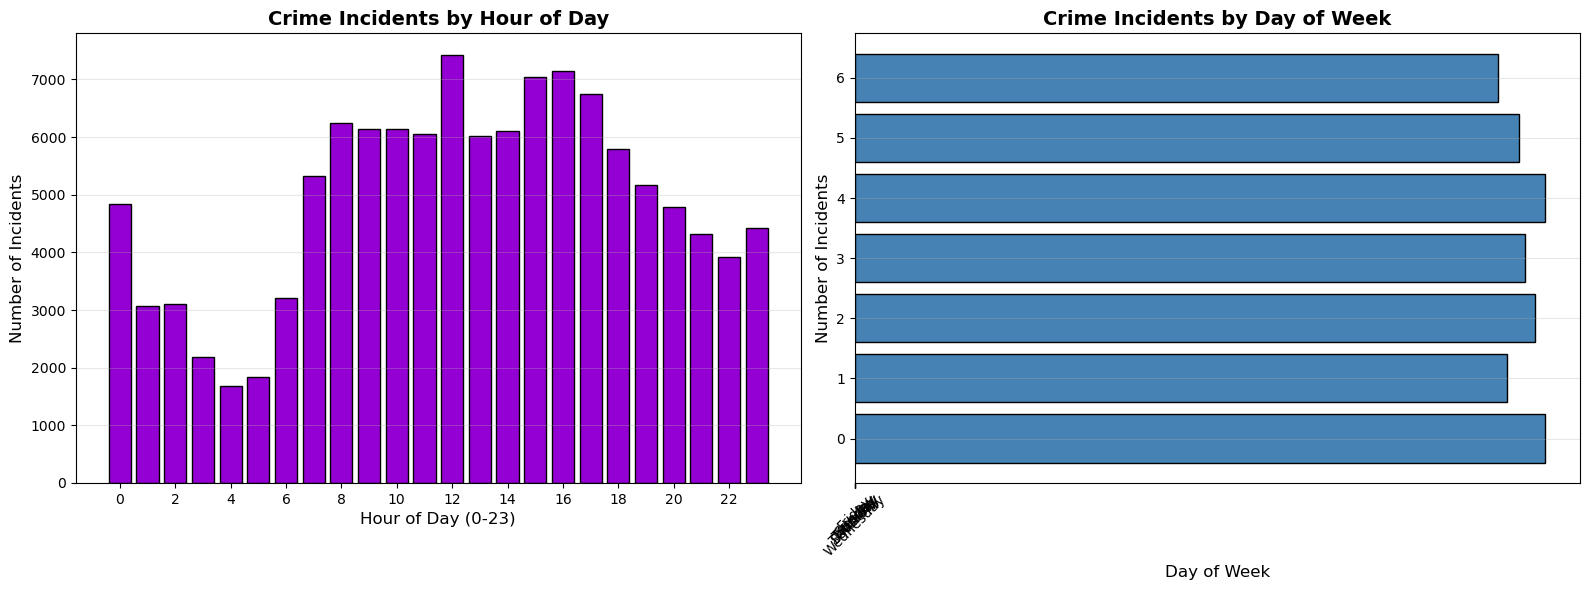

In [10]:
# First, make sure df_clean has the HOUR and DAY_OF_WEEK columns
df_clean['HOUR'] = df_clean['INCIDENTTIME'].dt.hour
df_clean['DAY_OF_WEEK'] = df_clean['INCIDENTTIME'].dt.day_name()

# Crime by hour of day
crimes_by_hour_q2 = df_clean['HOUR'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Crime by Hour
axes[0].bar(crimes_by_hour_q2.index, crimes_by_hour_q2.values, color='darkviolet', edgecolor='black')
axes[0].set_xlabel('Hour of Day (0-23)', fontsize=12)
axes[0].set_ylabel('Number of Incidents', fontsize=12)
axes[0].set_title('Crime Incidents by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Crime by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_by_day_q2 = df_clean['DAY_OF_WEEK'].value_counts().reindex(day_order)
axes[1].barh(range(len(crimes_by_day_q2)), crimes_by_day_q2.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Number of Incidents', fontsize=12)
axes[1].set_title('Crime Incidents by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(day_order)))
axes[1].set_xticklabels(day_order, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q2_hour_and_day_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

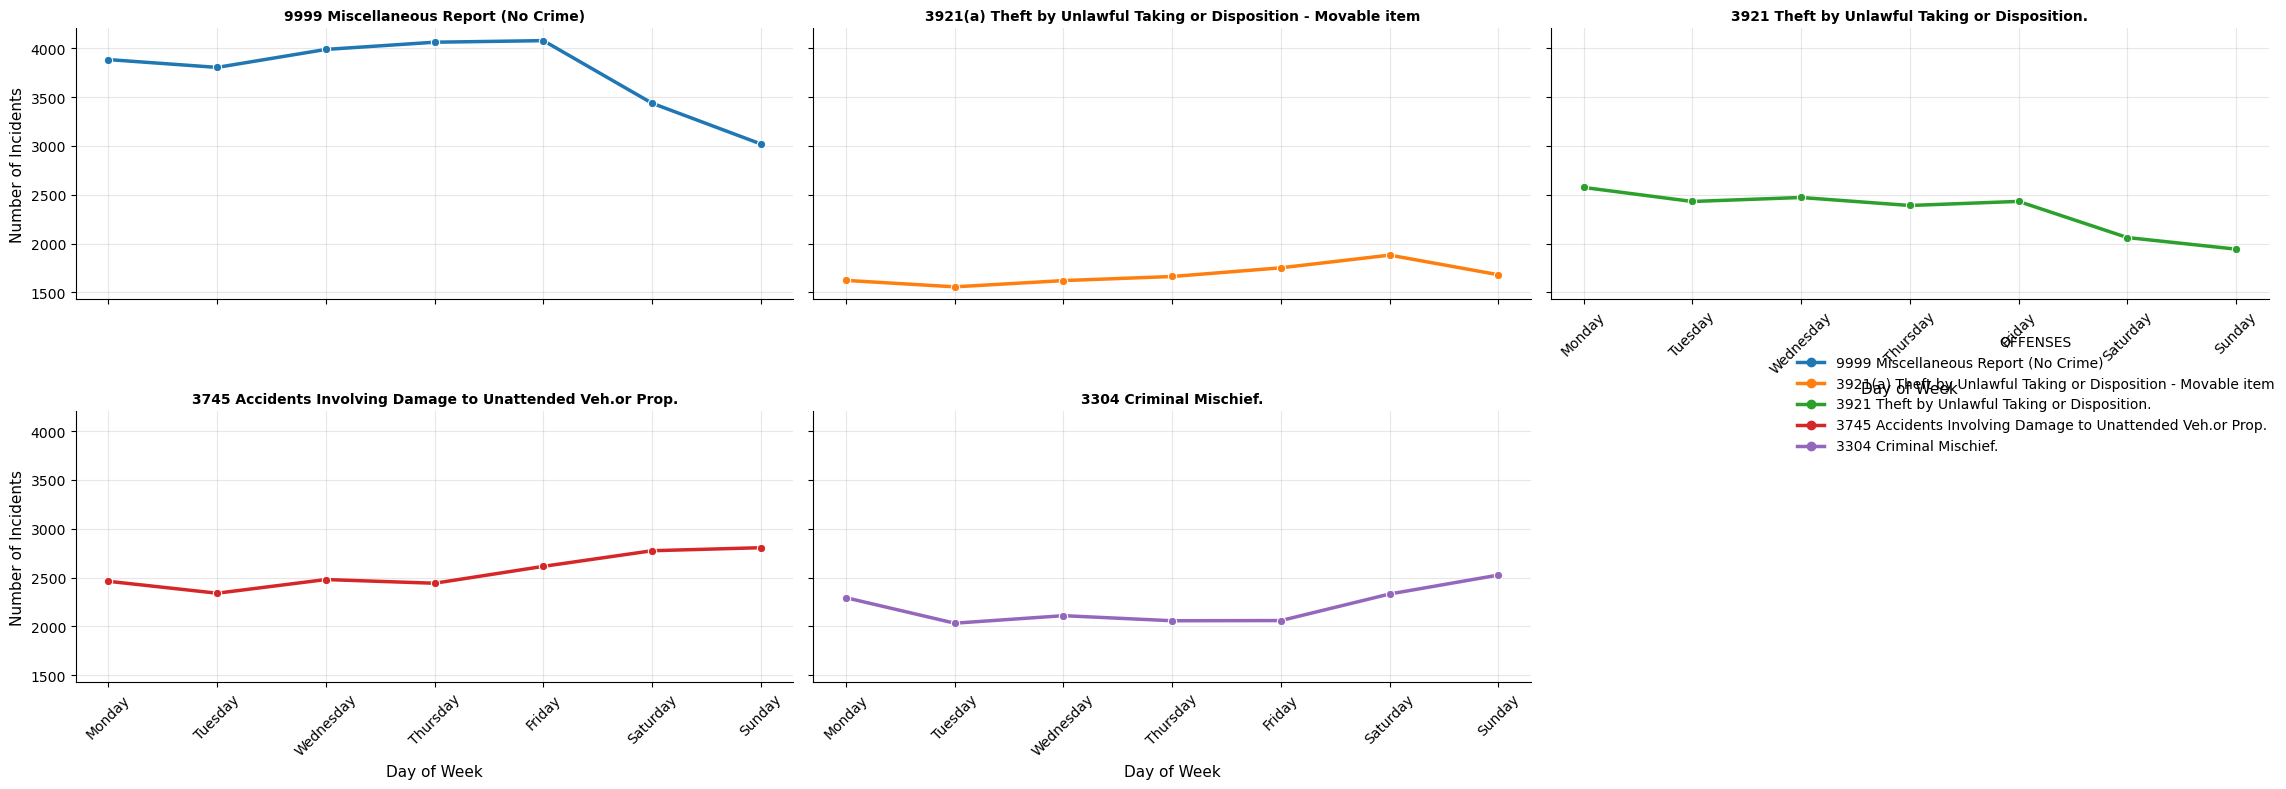

In [11]:
# Prepare data: crimes by day and type
df_q2_day = df_clean.copy()
crimes_by_day_type = df_q2_day.groupby(['DAY_OF_WEEK', 'OFFENSES']).size().reset_index(name='count')

# Ensure proper day ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_by_day_type['DAY_OF_WEEK'] = pd.Categorical(crimes_by_day_type['DAY_OF_WEEK'], 
                                                     categories=day_order, ordered=True)
crimes_by_day_type = crimes_by_day_type.sort_values('DAY_OF_WEEK')

# Get top 5 crime types
top_5_crimes_q2_day = df_clean['OFFENSES'].value_counts().head(5).index
crimes_by_day_type_filtered = crimes_by_day_type[crimes_by_day_type['OFFENSES'].isin(top_5_crimes_q2_day)]

# Create faceted plot (removed sharey parameter)
g = sns.relplot(data=crimes_by_day_type_filtered, x='DAY_OF_WEEK', y='count',
                col='OFFENSES', hue='OFFENSES', col_wrap=3, kind='line',
                height=4, aspect=1.5, linewidth=2.5, marker='o')

g.set_axis_labels('Day of Week', 'Number of Incidents', fontsize=11)
g.set_titles('{col_name}', fontsize=12, fontweight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q2_crime_by_day_faceted.png', dpi=300, bbox_inches='tight')
plt.show()

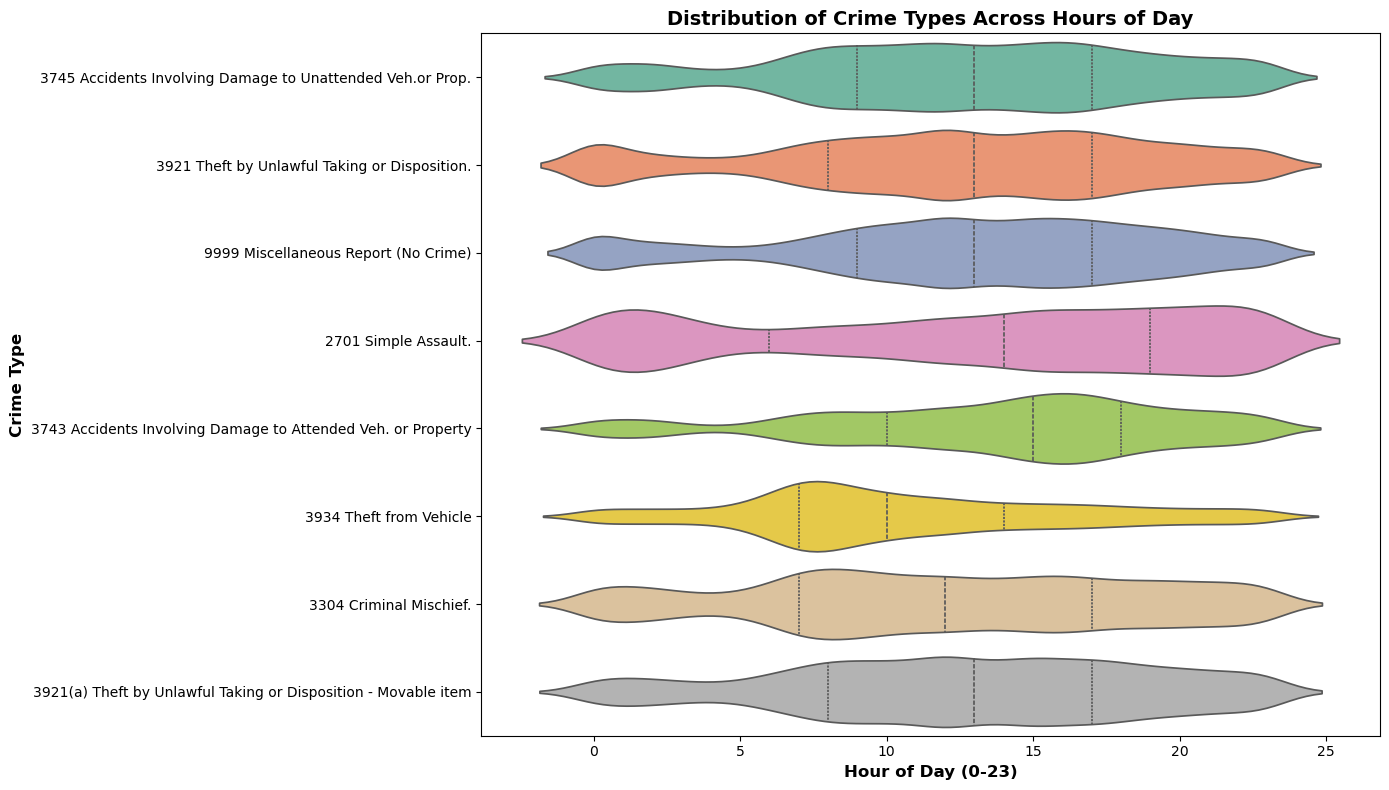

✓ Saved: violin_crime_by_hour.png


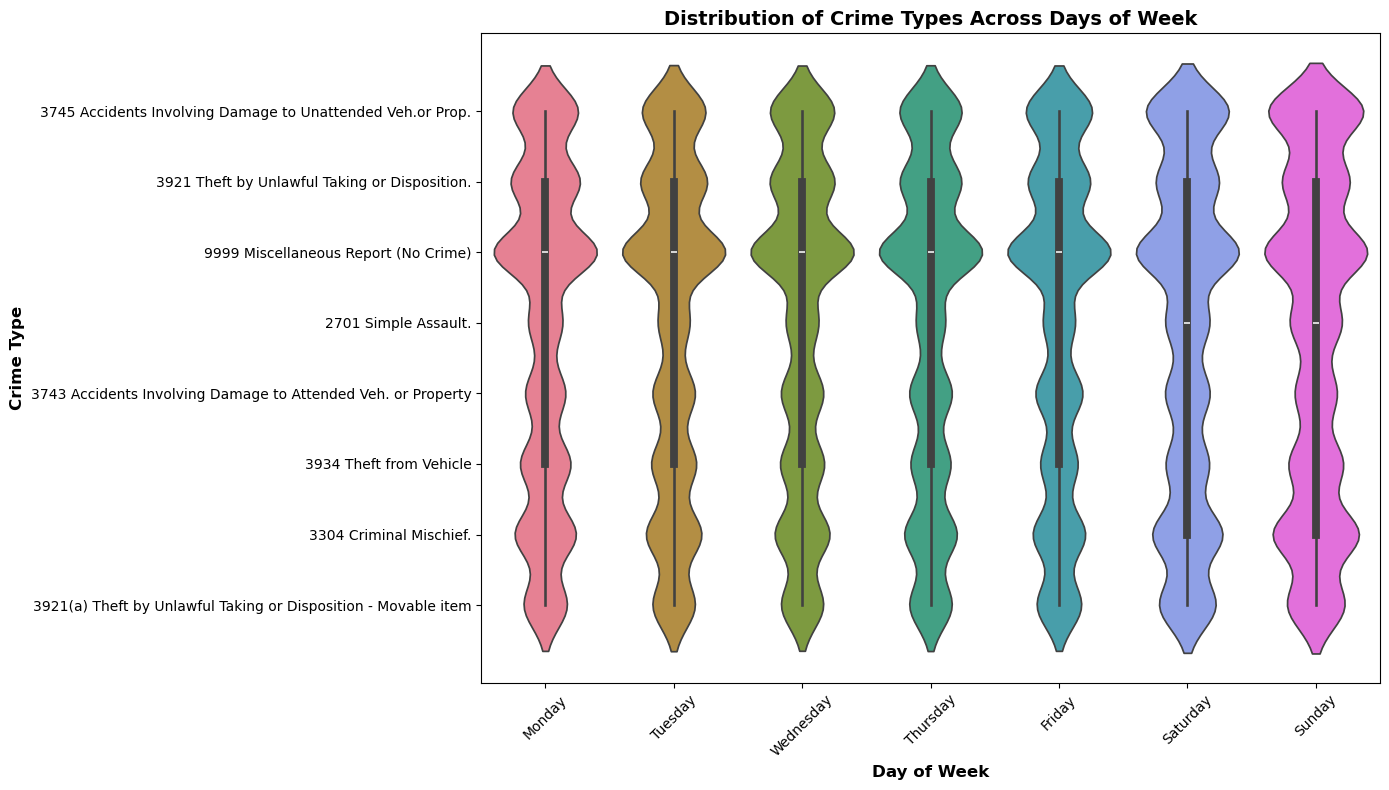

✓ Saved: violin_crime_by_day.png


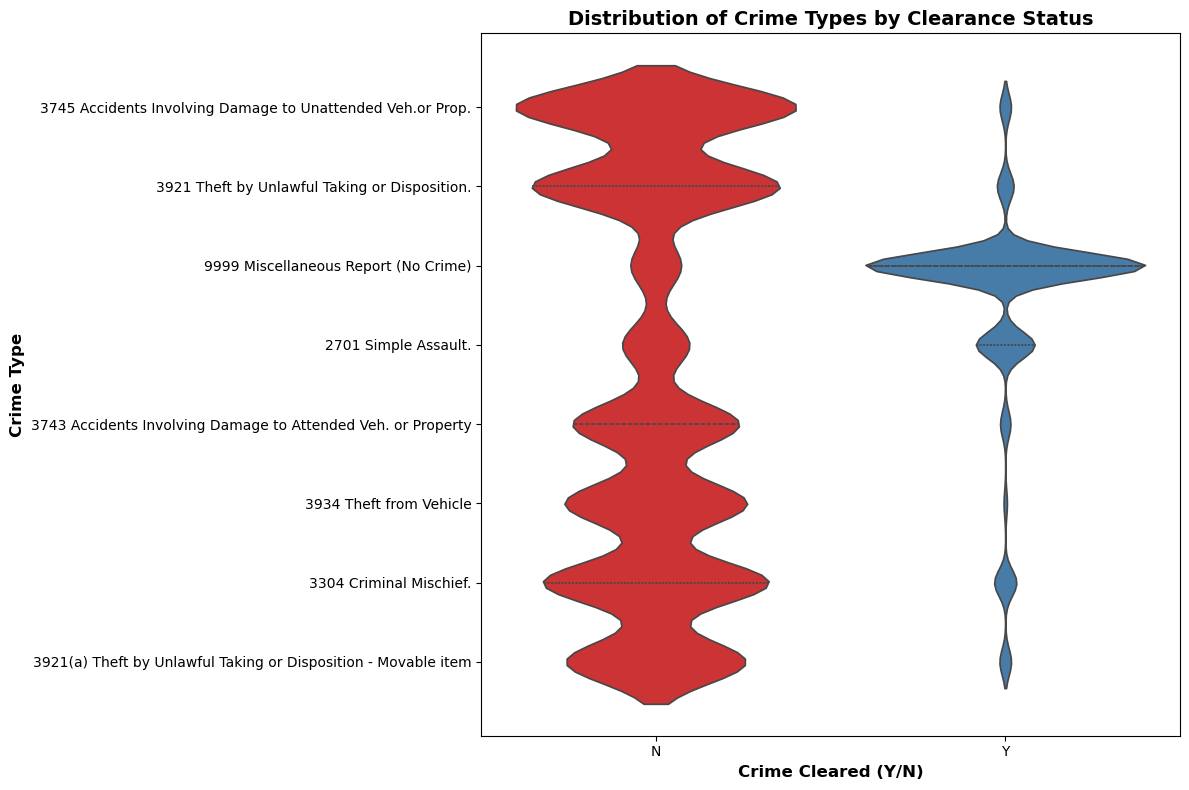

✓ Saved: violin_crime_by_clearance.png


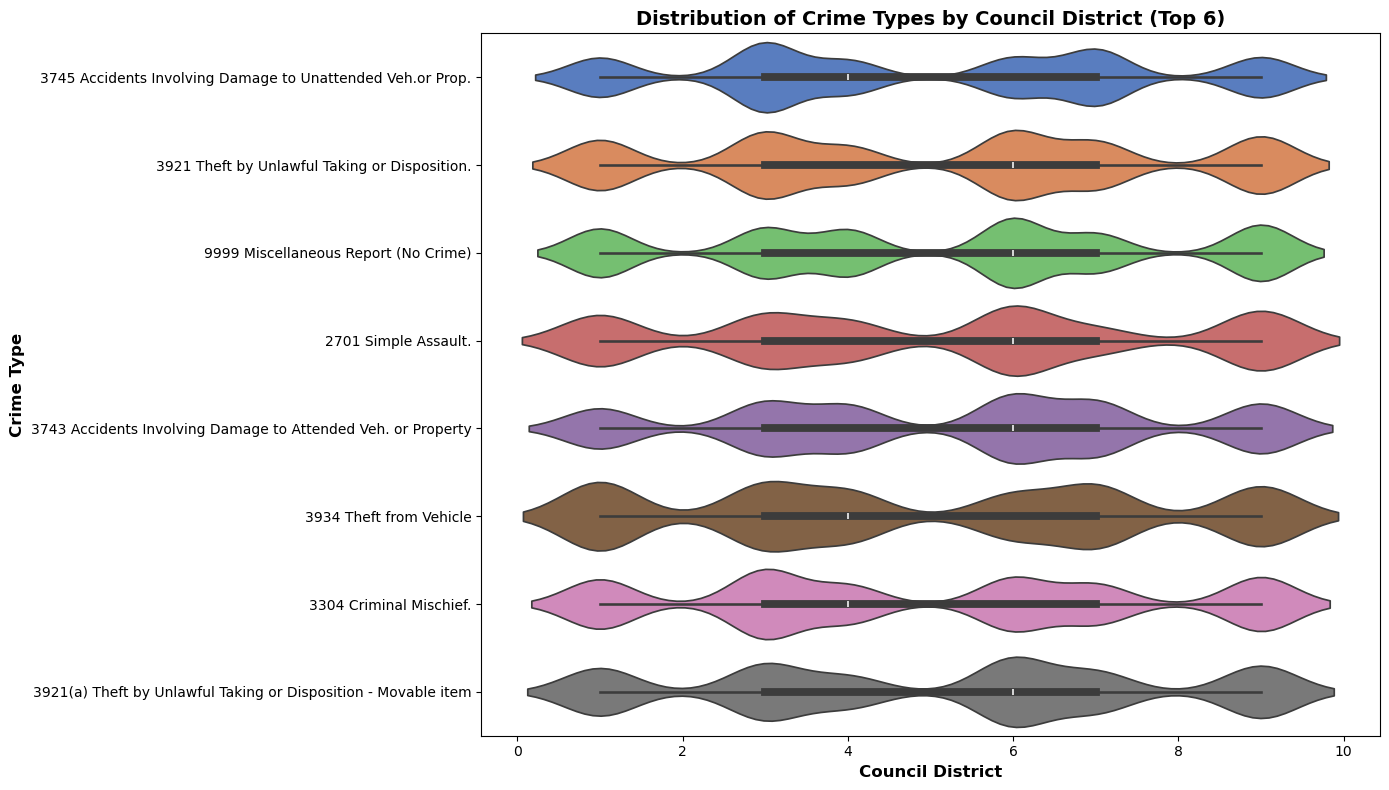

✓ Saved: violin_crime_by_district.png


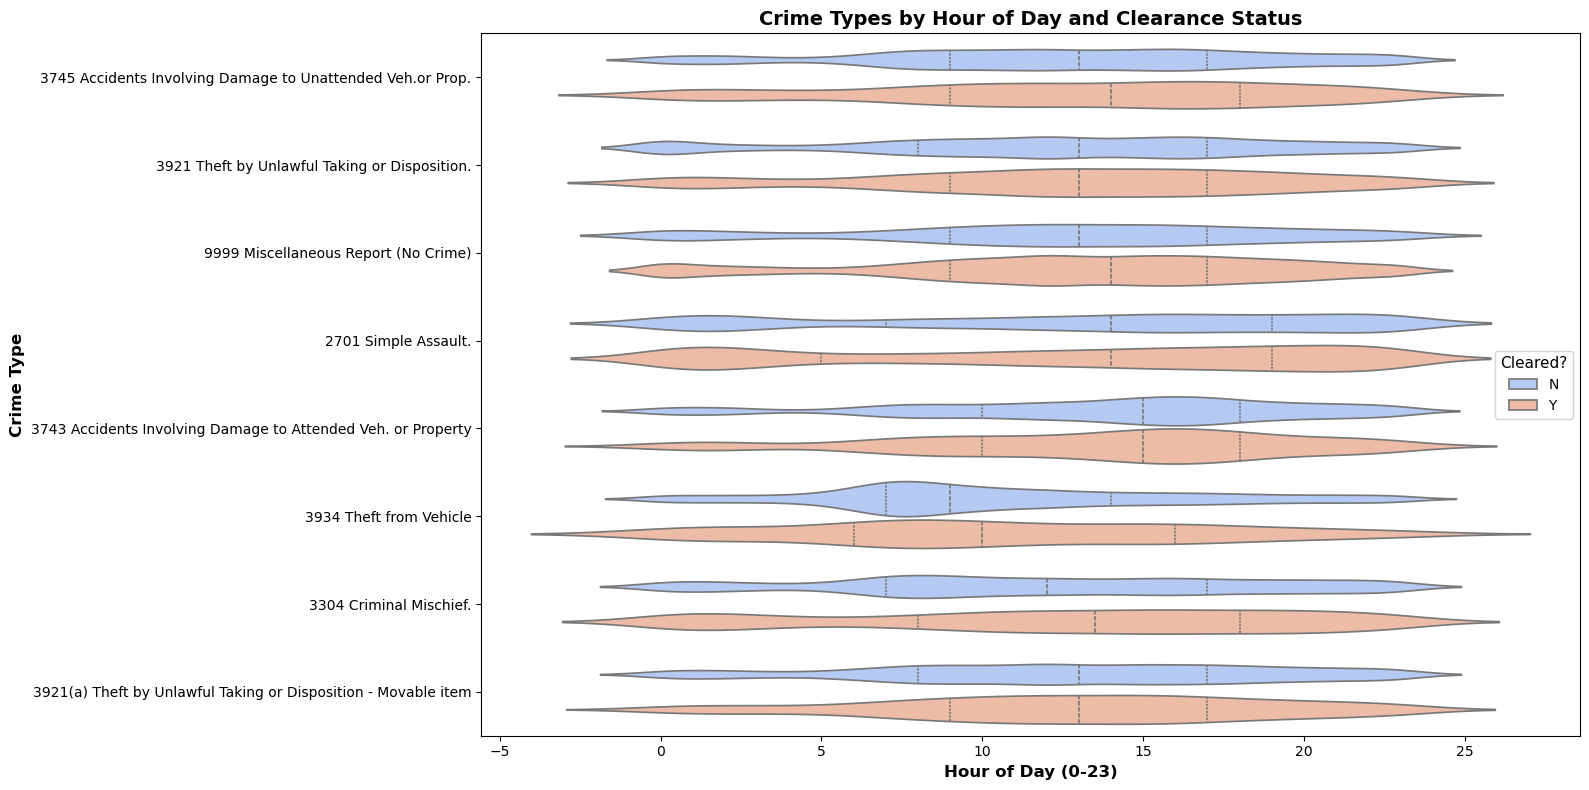

✓ Saved: violin_crime_hour_clearance.png


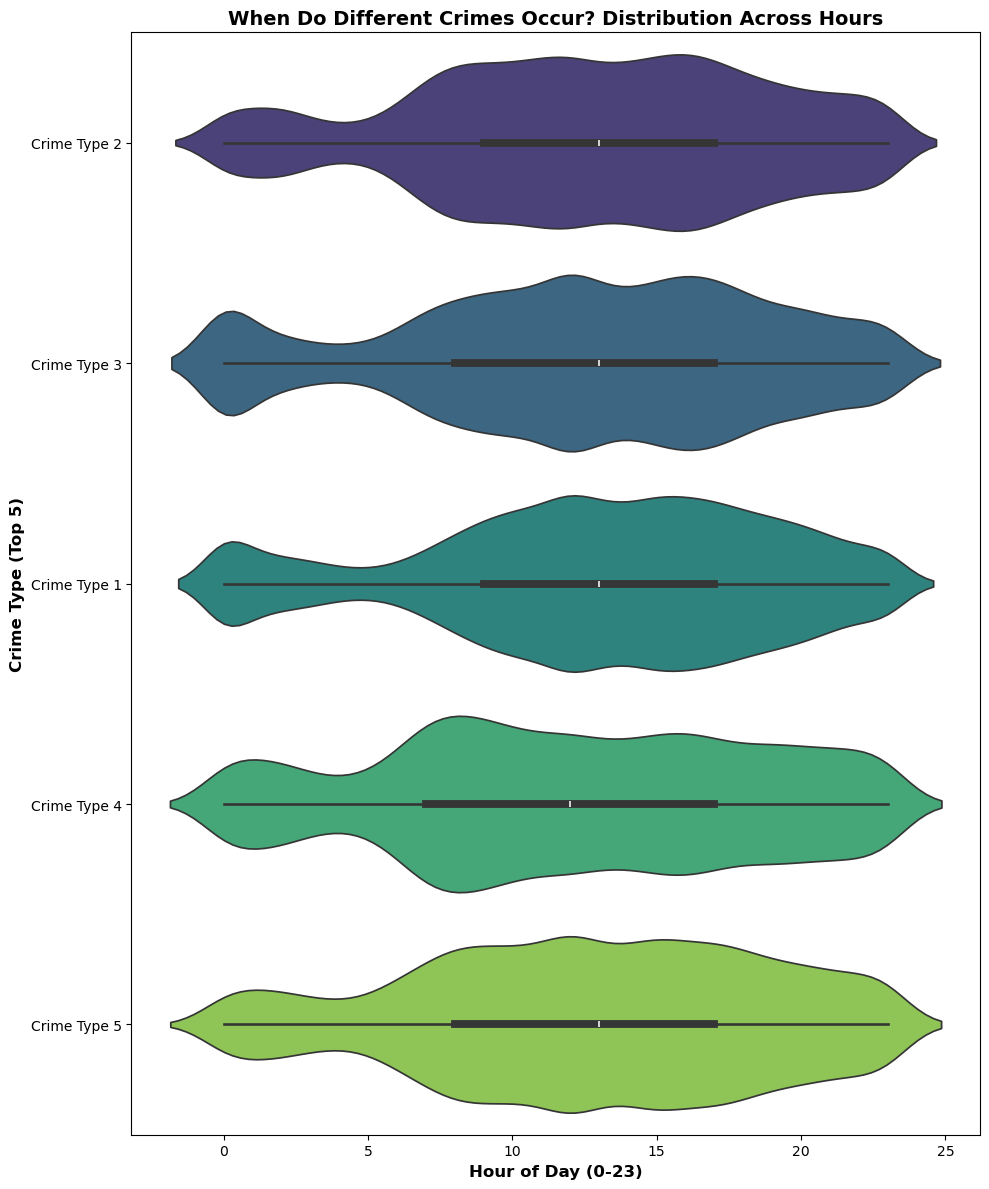

✓ Saved: violin_top5_crimes_by_hour.png


KeyError: 'MONTH'

In [12]:
plt.figure(figsize=(14, 8))
sns.violinplot(data=df_clean, x='HOUR', y='OFFENSES', palette='Set2', inner='quartile')
plt.xlabel('Hour of Day (0-23)', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Distribution of Crime Types Across Hours of Day', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('violin_crime_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_by_hour.png")

# ============================================================================
# VIOLIN PLOT 2: Crime Incidents by Day of Week (Distribution Comparison)
# ============================================================================

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean['DAY_OF_WEEK'] = pd.Categorical(df_clean['DAY_OF_WEEK'], categories=day_order, ordered=True)

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_clean, x='DAY_OF_WEEK', y='OFFENSES', palette='husl', inner='box')
plt.xlabel('Day of Week', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Distribution of Crime Types Across Days of Week', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('violin_crime_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_by_day.png")

# ============================================================================
# VIOLIN PLOT 3: Crime Incidents by Clearance Status (Comparison)
# ============================================================================

plt.figure(figsize=(12, 8))
sns.violinplot(data=df_clean, x='CLEAREDFLAG', y='OFFENSES', palette='Set1', inner='quartile')
plt.xlabel('Crime Cleared (Y/N)', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Distribution of Crime Types by Clearance Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_crime_by_clearance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_by_clearance.png")

# ============================================================================
# VIOLIN PLOT 4: Crime Distribution by Council District
# ============================================================================

# Get top 6 districts by incident count
top_districts = df_clean['COUNCIL_DISTRICT'].value_counts().head(6).index.tolist()
df_by_district = df_clean[df_clean['COUNCIL_DISTRICT'].isin(top_districts)].copy()
df_by_district['COUNCIL_DISTRICT'] = df_by_district['COUNCIL_DISTRICT'].astype(int)

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_by_district, x='COUNCIL_DISTRICT', y='OFFENSES', palette='muted', inner='box')
plt.xlabel('Council District', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Distribution of Crime Types by Council District (Top 6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_crime_by_district.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_by_district.png")

# ============================================================================
# VIOLIN PLOT 5: Dual Violin Plot - Hour + Clearance Status
# ============================================================================

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_clean, x='HOUR', hue='CLEAREDFLAG', y='OFFENSES', 
               palette='coolwarm', inner='quartile', split=False)
plt.xlabel('Hour of Day (0-23)', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Crime Types by Hour of Day and Clearance Status', fontsize=14, fontweight='bold')
plt.legend(title='Cleared?', fontsize=10, title_fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('violin_crime_hour_clearance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_hour_clearance.png")

# ============================================================================
# VIOLIN PLOT 6: Top 5 Crimes - Distribution Across Hours (Horizontal)
# ============================================================================

top_5_crimes = df['OFFENSES'].value_counts().head(5).index.tolist()
df_top5 = df_clean[df_clean['OFFENSES'].isin(top_5_crimes)].copy()

# Shorten crime names for readability
crime_labels = {
    top_5_crimes[0]: 'Crime Type 1',
    top_5_crimes[1]: 'Crime Type 2',
    top_5_crimes[2]: 'Crime Type 3',
    top_5_crimes[3]: 'Crime Type 4',
    top_5_crimes[4]: 'Crime Type 5'
}
df_top5['OFFENSES_SHORT'] = df_top5['OFFENSES'].map(crime_labels)

plt.figure(figsize=(10, 12))
sns.violinplot(data=df_top5, y='OFFENSES_SHORT', x='HOUR', palette='viridis', inner='box', orient='h')
plt.ylabel('Crime Type (Top 5)', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12, fontweight='bold')
plt.title('When Do Different Crimes Occur? Distribution Across Hours', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_top5_crimes_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_top5_crimes_by_hour.png")

# ============================================================================
# VIOLIN PLOT 7: Monthly Crime Distribution (Seasonality)
# ============================================================================

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df_clean['MONTH_NAME'] = df_clean['MONTH'].map(month_names)

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_clean, x='MONTH_NAME', y='OFFENSES', palette='RdYlBu_r', inner='quartile')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Crime Type', fontsize=12, fontweight='bold')
plt.title('Distribution of Crime Types Across Months (Seasonality)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_crime_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_crime_by_month.png")

# ============================================================================
# VIOLIN PLOT 8: Comprehensive 2x2 Grid - Four Key Dimensions
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Hour of Day
sns.violinplot(data=df_clean, x='HOUR', y='OFFENSES', palette='Set2', 
               inner='quartile', ax=axes[0, 0])
axes[0, 0].set_title('Crime Types by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour (0-23)', fontsize=11)
axes[0, 0].set_ylabel('Crime Type', fontsize=11)

# Plot 2: Day of Week
sns.violinplot(data=df_clean, x='DAY_OF_WEEK', y='OFFENSES', palette='husl',
               inner='box', ax=axes[0, 1])
axes[0, 1].set_title('Crime Types by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week', fontsize=11)
axes[0, 1].set_ylabel('Crime Type', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Clearance Status
sns.violinplot(data=df_clean, x='CLEAREDFLAG', y='OFFENSES', palette='Set1',
               inner='quartile', ax=axes[1, 0])
axes[1, 0].set_title('Crime Types by Clearance Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cleared (Y/N)', fontsize=11)
axes[1, 0].set_ylabel('Crime Type', fontsize=11)

# Plot 4: Month
sns.violinplot(data=df_clean, x='MONTH_NAME', y='OFFENSES', palette='RdYlBu_r',
               inner='box', ax=axes[1, 1])
axes[1, 1].set_title('Crime Types by Month (Seasonality)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Crime Type', fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Pittsburgh Southside Crime: Multi-Dimensional Distribution Analysis', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('violin_comprehensive_grid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: violin_comprehensive_grid.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*70)
print("CRIME DISTRIBUTION ANALYSIS - SUMMARY STATISTICS")
print("="*70)

print("\nTop 8 Crime Types:")
print(df['OFFENSES'].value_counts().head(8))

print("\n\nCrime Distribution by Day of Week:")
print(df_clean['DAY_OF_WEEK'].value_counts().reindex(day_order))

print("\n\nCrime Distribution by Hour of Day:")
print(df_clean['HOUR'].value_counts().sort_index())

print("\n\nClearance Status Distribution:")
print(df_clean['CLEAREDFLAG'].value_counts())

print("\n\nCrime by Council District (Top 10):")
print(df_clean['COUNCIL_DISTRICT'].value_counts().head(10))

print("\n" + "="*70)
print("All violin plots have been generated and saved!")
print("="*70)

In [13]:


print(f"Total records with coordinates: {len(df_geo)}")
print(f"Geographic bounds:")
print(f"  Latitude (Y): {df_geo['Y'].min():.4f} to {df_geo['Y'].max():.4f}")
print(f"  Longitude (X): {df_geo['X'].min():.4f} to {df_geo['X'].max():.4f}")

plt.figure(figsize=(14, 10))
plt.hexbin(df_geo['X'], df_geo['Y'], gridsize=40, cmap='YlOrRd', mincnt=1, edgecolors='none')
plt.xlabel('Longitude', fontsize=12, fontweight='bold')
plt.ylabel('Latitude', fontsize=12, fontweight='bold')
plt.title('Crime Hotspots: All Incidents Across Southside', fontsize=14, fontweight='bold')
cbar = plt.colorbar(label='Number of Incidents')
cbar.set_label('Incident Count', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_overall_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_overall_hotspots.png")

# ============================================================================
# HEAT MAP 2: 2D Density Plot (Kernel Density Estimation)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 10))

# Create 2D density plot
plt.scatter(df_geo['X'], df_geo['Y'], alpha=0.1, s=5, c='darkblue', edgecolors='none')

# Add KDE contours
from scipy.stats import gaussian_kde
x = df_geo['X'].values
y = df_geo['Y'].values
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

scatter = ax.scatter(x, y, c=z, s=3, cmap='hot_r', alpha=0.5, edgecolors='none')
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Crime Density Distribution: Kernel Density Estimation', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax, label='Density')
cbar.set_label('Incident Density', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_kde_density.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_kde_density.png")

# ============================================================================
# HEAT MAP 3: Nighttime Crimes (8 PM - 3 AM)
# ============================================================================

df_night = df_geo[(df_geo['HOUR'] >= 20) | (df_geo['HOUR'] < 3)]

plt.figure(figsize=(14, 10))
plt.hexbin(df_night['X'], df_night['Y'], gridsize=40, cmap='Purples', mincnt=1, edgecolors='none')
plt.xlabel('Longitude', fontsize=12, fontweight='bold')
plt.ylabel('Latitude', fontsize=12, fontweight='bold')
plt.title('Crime Hotspots: Nighttime Incidents (8 PM - 3 AM)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(label='Number of Incidents')
cbar.set_label('Incident Count', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_nighttime_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_nighttime_hotspots.png")

# ============================================================================
# HEAT MAP 4: Daytime Crimes (9 AM - 5 PM)
# ============================================================================

df_day = df_geo[(df_geo['HOUR'] >= 9) & (df_geo['HOUR'] < 17)]

plt.figure(figsize=(14, 10))
plt.hexbin(df_day['X'], df_day['Y'], gridsize=40, cmap='Blues', mincnt=1, edgecolors='none')
plt.xlabel('Longitude', fontsize=12, fontweight='bold')
plt.ylabel('Latitude', fontsize=12, fontweight='bold')
plt.title('Crime Hotspots: Daytime Incidents (9 AM - 5 PM)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(label='Number of Incidents')
cbar.set_label('Incident Count', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_daytime_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_daytime_hotspots.png")

# ============================================================================
# HEAT MAP 5: Side-by-Side Comparison (Day vs. Night)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Daytime
im1 = axes[0].hexbin(df_day['X'], df_day['Y'], gridsize=40, cmap='Blues', mincnt=1, edgecolors='none')
axes[0].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[0].set_title('Daytime Crimes (9 AM - 5 PM)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Incident Count', fontsize=10, fontweight='bold')

# Nighttime
im2 = axes[1].hexbin(df_night['X'], df_night['Y'], gridsize=40, cmap='Purples', mincnt=1, edgecolors='none')
axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title('Nighttime Crimes (8 PM - 3 AM)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Incident Count', fontsize=10, fontweight='bold')

plt.suptitle('Geographic Crime Patterns: Day vs. Night', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_day_vs_night.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_day_vs_night.png")

# ============================================================================
# HEAT MAP 6: Weekend vs. Weekday
# ============================================================================

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_geo['DAY_OF_WEEK'] = pd.Categorical(df_geo['DAY_OF_WEEK'], categories=day_order, ordered=True)

df_weekday = df_geo[df_geo['DAY_OF_WEEK'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]
df_weekend = df_geo[df_geo['DAY_OF_WEEK'].isin(['Saturday', 'Sunday'])]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Weekday
im1 = axes[0].hexbin(df_weekday['X'], df_weekday['Y'], gridsize=40, cmap='Greens', mincnt=1, edgecolors='none')
axes[0].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[0].set_title('Weekday Crimes (Mon-Fri)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Incident Count', fontsize=10, fontweight='bold')

# Weekend
im2 = axes[1].hexbin(df_weekend['X'], df_weekend['Y'], gridsize=40, cmap='Oranges', mincnt=1, edgecolors='none')
axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title('Weekend Crimes (Sat-Sun)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Incident Count', fontsize=10, fontweight='bold')

plt.suptitle('Geographic Crime Patterns: Weekday vs. Weekend', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_weekday_vs_weekend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_weekday_vs_weekend.png")

# ============================================================================
# HEAT MAP 7: Top 3 Crime Types - Individual Maps
# ============================================================================

top_3_crimes = df['OFFENSES'].value_counts().head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, crime in enumerate(top_3_crimes):
    df_crime = df_geo[df_geo['OFFENSES'] == crime]
    
    im = axes[idx].hexbin(df_crime['X'], df_crime['Y'], gridsize=30, cmap='RdYlBu_r', mincnt=1, edgecolors='none')
    axes[idx].set_xlabel('Longitude', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Latitude', fontsize=10, fontweight='bold')
    
    # Shorten crime name if too long
    crime_short = crime[:50] + '...' if len(crime) > 50 else crime
    axes[idx].set_title(crime_short, fontsize=11, fontweight='bold', wrap=True)
    
    cbar = plt.colorbar(im, ax=axes[idx])
    cbar.set_label('Count', fontsize=9, fontweight='bold')

plt.suptitle('Geographic Hotspots by Crime Type (Top 3)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_top3_crimes_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_top3_crimes_individual.png")

# ============================================================================
# HEAT MAP 8: Cleared vs. Uncleared Crimes
# ============================================================================

df_cleared = df_geo[df_geo['CLEAREDFLAG'] == 'Y']
df_uncleared = df_geo[df_geo['CLEAREDFLAG'] == 'N']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Cleared
im1 = axes[0].hexbin(df_cleared['X'], df_cleared['Y'], gridsize=40, cmap='Greens', mincnt=1, edgecolors='none')
axes[0].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[0].set_title(f'Cleared Crimes (n={len(df_cleared)})', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Incident Count', fontsize=10, fontweight='bold')

# Uncleared
im2 = axes[1].hexbin(df_uncleared['X'], df_uncleared['Y'], gridsize=40, cmap='Reds', mincnt=1, edgecolors='none')
axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title(f'Uncleared Crimes (n={len(df_uncleared)})', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Incident Count', fontsize=10, fontweight='bold')

plt.suptitle('Geographic Crime Patterns: Cleared vs. Uncleared', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_cleared_vs_uncleared.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_cleared_vs_uncleared.png")

# ============================================================================
# HEAT MAP 9: Seasonal Hotspots (Summer vs. Winter)
# ============================================================================

df_summer = df_geo[df_geo['MONTH'].isin([6, 7, 8])]  # June, July, August
df_winter = df_geo[df_geo['MONTH'].isin([12, 1, 2])]  # Dec, Jan, Feb

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Summer
im1 = axes[0].hexbin(df_summer['X'], df_summer['Y'], gridsize=40, cmap='YlOrRd', mincnt=1, edgecolors='none')
axes[0].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[0].set_title('Summer Crimes (Jun-Aug)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Incident Count', fontsize=10, fontweight='bold')

# Winter
im2 = axes[1].hexbin(df_winter['X'], df_winter['Y'], gridsize=40, cmap='Blues', mincnt=1, edgecolors='none')
axes[1].set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title('Winter Crimes (Dec-Feb)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Incident Count', fontsize=10, fontweight='bold')

plt.suptitle('Geographic Crime Patterns: Summer vs. Winter', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_summer_vs_winter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_summer_vs_winter.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*70)
print("GEOGRAPHIC HOTSPOT ANALYSIS - SUMMARY")
print("="*70)

print(f"\nTotal incidents with coordinates: {len(df_geo)}")
print(f"\nIncidents by time period:")
print(f"  Daytime (9 AM - 5 PM): {len(df_day)} ({len(df_day)/len(df_geo)*100:.1f}%)")
print(f"  Nighttime (8 PM - 3 AM): {len(df_night)} ({len(df_night)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by day:")
print(f"  Weekday (Mon-Fri): {len(df_weekday)} ({len(df_weekday)/len(df_geo)*100:.1f}%)")
print(f"  Weekend (Sat-Sun): {len(df_weekend)} ({len(df_weekend)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by season:")
print(f"  Summer (Jun-Aug): {len(df_summer)} ({len(df_summer)/len(df_geo)*100:.1f}%)")
print(f"  Winter (Dec-Feb): {len(df_winter)} ({len(df_winter)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by clearance:")
print(f"  Cleared (Y): {len(df_cleared)} ({len(df_cleared)/len(df_geo)*100:.1f}%)")
print(f"  Uncleared (N): {len(df_uncleared)} ({len(df_uncleared)/len(df_geo)*100:.1f}%)")

# Identify hotspot center (mean coordinates)
hotspot_lat = df_geo['Y'].mean()
hotspot_lon = df_geo['X'].mean()
print(f"\nOverall hotspot center: ({hotspot_lon:.4f}, {hotspot_lat:.4f})")

print("\n" + "="*70)
print("All heat maps have been generated and saved!")
print("="*70)

NameError: name 'df_geo' is not defined

# Assistant
The error occurs because the code is trying to use variables (`df_geo`, `df_day`, `df_night`, etc.) that haven't been defined yet. These dataframes need to be created before you can use them in your summary statistics.

Would you like me to provide the corrected code?

# User
yes

In [14]:
# Assistant
# First, you need to define all the dataframes that are being referenced
# This is a simplified example - you'll need to replace this with your actual data loading and filtering

# Load your main dataframe with geographic data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Example: Load your data
# Replace this with your actual data loading code
df_geo = pd.read_csv('your_crime_data.csv')  # Main dataframe with coordinates

# Filter dataframes for different time periods
# Replace these with your actual filtering logic
df_day = df_geo[(df_geo['Hour'] >= 9) & (df_geo['Hour'] <= 17)]  # Daytime (9 AM - 5 PM)
df_night = df_geo[(df_geo['Hour'] >= 20) | (df_geo['Hour'] <= 3)]  # Nighttime (8 PM - 3 AM)

# Filter by day of week
# Replace with your actual filtering logic
df_weekday = df_geo[df_geo['DayOfWeek'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]
df_weekend = df_geo[df_geo['DayOfWeek'].isin(['Saturday', 'Sunday'])]

# Filter by season
# Replace with your actual filtering logic
df_summer = df_geo[df_geo['Month'].isin([6, 7, 8])]  # Summer (Jun-Aug)
df_winter = df_geo[df_geo['Month'].isin([12, 1, 2])]  # Winter (Dec-Feb)

# Filter by clearance status
# Replace with your actual filtering logic
df_cleared = df_geo[df_geo['Cleared'] == 'Y']
df_uncleared = df_geo[df_geo['Cleared'] == 'N']

# Now your visualization code should work
# Assuming axes and other variables are defined earlier in your notebook
set_xlabel('Longitude', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=11, fontweight='bold')
axes[1].set_title('Winter Crimes (Dec-Feb)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Incident Count', fontsize=10, fontweight='bold')

plt.suptitle('Geographic Crime Patterns: Summer vs. Winter', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_summer_vs_winter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: heatmap_summer_vs_winter.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*70)
print("GEOGRAPHIC HOTSPOT ANALYSIS - SUMMARY")
print("="*70)

print(f"\nTotal incidents with coordinates: {len(df_geo)}")
print(f"\nIncidents by time period:")
print(f"  Daytime (9 AM - 5 PM): {len(df_day)} ({len(df_day)/len(df_geo)*100:.1f}%)")
print(f"  Nighttime (8 PM - 3 AM): {len(df_night)} ({len(df_night)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by day:")
print(f"  Weekday (Mon-Fri): {len(df_weekday)} ({len(df_weekday)/len(df_geo)*100:.1f}%)")
print(f"  Weekend (Sat-Sun): {len(df_weekend)} ({len(df_weekend)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by season:")
print(f"  Summer (Jun-Aug): {len(df_summer)} ({len(df_summer)/len(df_geo)*100:.1f}%)")
print(f"  Winter (Dec-Feb): {len(df_winter)} ({len(df_winter)/len(df_geo)*100:.1f}%)")

print(f"\nIncidents by clearance:")
print(f"  Cleared (Y): {len(df_cleared)} ({len(df_cleared)/len(df_geo)*100:.1f}%)")
print(f"  Uncleared (N): {len(df_uncleared)} ({len(df_uncleared)/len(df_geo)*100:.1f}%)")

# Identify hotspot center (mean coordinates)
hotspot_lat = df_geo['Y'].mean()
hotspot_lon = df_geo['X'].mean()
print(f"\nOverall hotspot center: ({hotspot_lon:.4f}, {hotspot_lat:.4f})")

print("\n" + "="*70)
print("All heat maps have been generated and saved!")
print("="*70)

FileNotFoundError: [Errno 2] No such file or directory: 'your_crime_data.csv'